# Mozambique 2023 mVAM preprocessing — tidy version with climate/admin reference

This notebook rewrites the original exploratory `explore_2023.ipynb` as a clean preprocessing pipeline.

Main choices:

- the 2023 survey remains the source for household/food-security variables;
- feature names are kept exactly as they appear in the original survey file, for example `FCS`, `rCSI`, `FGVitA`, `FGProtein`, `FGHIron`;
- `/data/shared/fsibilla/DATA_PROCESSING/moz_mvam/climate_medians.csv` is used as the canonical source for ADM1/ADM2 codes, names, geometries, and climate variables;
- merging uses ADM codes when available, otherwise normalized names;
- known Mozambique name aliases are applied before the name-based fallback, including `Cabo Delg -> Cabo Delgado`.

In [49]:
from pathlib import Path
import json
import re
import unicodedata
import warnings

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely import wkt
from shapely.geometry import shape
from shapely.geometry.base import BaseGeometry

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 120)

In [50]:
# Paths
BASE_IN = Path("/data/shared/fsibilla/wfp-da4hd/DATA/in/moz/mozambique_ Post Shock Food Security Assessment 2023")
BASE_OUT = Path("/data/shared/fsibilla/DATA_PROCESSING/moz_mvam")
BASE_OUT.mkdir(parents=True, exist_ok=True)

SURVEY_PATH = BASE_IN / "base-de-dados-de-san-ponderada-pelo-ine-2023.sav"
CLIMATE_MEDIANS_PATH = BASE_OUT / "climate_medians.csv"

ENTROPY_TIF_PATH = Path("/data/shared/fsibilla/wfp-da4hd/DATA/in/moz/entropy_mod_4h_moto.tif")
RWI_CSV_PATH = Path("/data/shared/fsibilla/wfp-da4hd/DATA/in/moz/MOZ_relative_wealth_index.csv")

FINAL_CSV_PATH = BASE_OUT / "full_2023.csv"
LEGACY_FINAL_CSV_PATH = Path("/data/shared/fsibilla/clean_code/Q1/experiments/moz_vam/full.csv")
FIG_PATH = BASE_OUT / "maps_and_histograms_2023.png"

print("Survey path:", SURVEY_PATH)
print("Climate/admin reference path:", CLIMATE_MEDIANS_PATH)
print("Entropy raster path:", ENTROPY_TIF_PATH)
print("RWI CSV path:", RWI_CSV_PATH)
print("Output path:", FINAL_CSV_PATH)

Survey path: /data/shared/fsibilla/wfp-da4hd/DATA/in/moz/mozambique_ Post Shock Food Security Assessment 2023/base-de-dados-de-san-ponderada-pelo-ine-2023.sav
Climate/admin reference path: /data/shared/fsibilla/DATA_PROCESSING/moz_mvam/climate_medians.csv
Entropy raster path: /data/shared/fsibilla/wfp-da4hd/DATA/in/moz/entropy_mod_4h_moto.tif
RWI CSV path: /data/shared/fsibilla/wfp-da4hd/DATA/in/moz/MOZ_relative_wealth_index.csv
Output path: /data/shared/fsibilla/DATA_PROCESSING/moz_mvam/full_2023.csv


## Helper functions

In [51]:
def show_shape(name, df):
    print(f"{name}: {df.shape[0]:,} rows x {df.shape[1]:,} columns")


def strip_accents(s):
    s = unicodedata.normalize("NFKD", str(s))
    return "".join(c for c in s if not unicodedata.combining(c))


def normalize_name(x):
    """
    Normalize names for robust matching:
    - lowercase
    - remove accents
    - replace underscores/punctuation with spaces
    - collapse spaces
    """
    if pd.isna(x):
        return ""
    s = strip_accents(x).lower().strip()
    s = s.replace("_", " ")
    s = re.sub(r"[^a-z0-9\s\-]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def apply_key_aliases(series, aliases):
    """Apply aliases after normalization, so aliases are written as normalized keys."""
    return series.replace(aliases)


def clean_code(x):
    """
    Make admin codes comparable:
    - string
    - remove spaces
    - remove trailing .0 from float-like codes
    - uppercase
    """
    if pd.isna(x):
        return ""
    s = str(x).strip()
    s = re.sub(r"\.0$", "", s)
    s = s.replace(" ", "")
    return s.upper()


def parse_geometry(x):
    """
    Convert geometry-like values to shapely geometries.
    Supports shapely objects, WKT strings, GeoJSON strings/dicts.
    """
    if isinstance(x, BaseGeometry):
        return x
    if pd.isna(x):
        return None
    if isinstance(x, dict):
        try:
            return shape(x)
        except Exception:
            return None
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return None
        try:
            return wkt.loads(s)
        except Exception:
            pass
        try:
            return shape(json.loads(s))
        except Exception:
            return None
    return None


def first_existing(columns, candidates):
    """Return the first candidate that exists in columns, case-insensitively."""
    columns = list(columns)
    lower_to_original = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand in columns:
            return cand
        if cand.lower() in lower_to_original:
            return lower_to_original[cand.lower()]
    return None


def find_code_col(columns, level):
    """Infer an ADM code column for a given level, e.g. 'adm1' or 'adm2'."""
    patterns = [
        rf"^{level}.*code$",
        rf"^{level}.*pcode$",
        rf"{level}.*code",
        rf"{level}.*pcode",
        rf"{level.upper()}.*CODE",
        rf"{level.upper()}.*PCODE",
    ]
    for c in columns:
        compact = re.sub(r"[^a-zA-Z0-9]", "", c)
        for pat in patterns:
            if re.search(pat, c, flags=re.IGNORECASE) or re.search(pat, compact, flags=re.IGNORECASE):
                return c
    return None


def geometry_to_wkt(g):
    if isinstance(g, BaseGeometry):
        return g.wkt
    return g

## Mozambique-specific name aliases

Aliases are applied to normalized merge keys. This keeps the merge logic simple and makes the few manual fixes explicit.

In [52]:
ADM1_KEY_ALIASES = {
    "zambezia": "zambezia",
    "zambezia province": "zambezia",

    "cabo delg": "cabo delgado",
    "cabo delgado": "cabo delgado",

    "maputo provinci": "maputo",
    "maputo provincia": "maputo",

    # Important: match climate reference
    "maputo cidade": "maputo city",
}

ADM2_KEY_ALIASES = {
    "cidade de xai xa": "cidade de xai-xai",
    "cidade de xai-xa": "cidade de xai-xai",

    "cidade de lichin": "cidade de lichinga",
    "mocimboa da prai": "mocimboa da praia",
    "cidade de nampul": "cidade de nampula",
    "cidade de quelim": "cidade de quelimane",
    "cidade de chimoi": "cidade de chimoio",
    "cidade de inhamb": "cidade de inhambane",

    "vilanculos": "vilankulo",
    "erati namapa": "erati",
    "cidade de matola": "cidade da matola",

    # Maputo City survey subdistricts -> climate ADM2 unit
    "kamavota": "cidade de maputo",
    "kamubukwana": "cidade de maputo",
    "kanyaka": "cidade de maputo",
    "katembe": "cidade de maputo",
}

## Load and clean survey data

In [53]:
df_raw = pd.read_spss(SURVEY_PATH)
show_shape("Raw survey", df_raw)
print("Raw columns:")
print(df_raw.columns.tolist())
display(df_raw.head())

Raw survey: 11,080 rows x 382 columns
Raw columns:
['SETSAN_ID_FINAL', 'CodProv2', 'Provinci_12', 'CodDist2', 'Distrito_22', 'CodPost2', 'Posto2', 'CodLocal2', 'Localida_12', 'CodBairro2', 'Bairro_12', 'CodN12', 'NomeN12', 'CodN22', 'NomeN22', 'CodN32', 'NomeN32', 'CodAE_2017', 'SETSA_IDJul', 'T_AFs_AE', 'AFEStratAGriPorDisUrRural', 'AEsPorDistUR', 'AEPorDistInquerito', 'AF_Esperados1', 'N_AFs', 'Listados', '@_id', 'SETANIDJul', 'FID2', 'Area_Geogr2', 'SETSAN_ID2', 'IDAGrPec2', 'CodPrDisUR2', 'AFEStratAG2', 'F_AEsPorDi2', 'CodSElec2', 'IDDANIEL2', 'BASEdeSPSS', 'INDEDANIEL', 'Provincia2', 'O1_Prov', 'O2_District', 'Distrito2', 'O3_Posto', '@_index', 'instanceID', '@_uuid', 'Area_de_Enumeracao_Numero', 'O7_GPS', '@_O7_GPS_latitude', '@_O7_GPS_longitude', '@_O7_GPS_altitude', '@_O7_GPS_precision', 'start', 'end', 'today', 'deviceid', 'phonenumber', 'O4_Localidade', 'O4_Bairro', 'zona', 'Numero_de_Agregado_Familiar', 'O9_NomeSup', 'O8_CodInquiridor', 'O7_CodEquipa', 'Gui_o_de_Apresenta_o_

,SETSAN_ID_FINAL,CodProv2,Provinci_12,CodDist2,Distrito_22,CodPost2,Posto2,CodLocal2,Localida_12,CodBairro2,Bairro_12,CodN12,NomeN12,CodN22,NomeN22,CodN32,NomeN32,CodAE_2017,SETSA_IDJul,T_AFs_AE,AFEStratAGriPorDisUrRural,AEsPorDistUR,AEPorDistInquerito,AF_Esperados1,N_AFs,Listados,@_id,SETANIDJul,FID2,Area_Geogr2,SETSAN_ID2,IDAGrPec2,CodPrDisUR2,AFEStratAG2,F_AEsPorDi2,CodSElec2,IDDANIEL2,BASEdeSPSS,INDEDANIEL,Provincia2,O1_Prov,O2_District,Distrito2,O3_Posto,@_index,instanceID,@_uuid,Area_de_Enumeracao_Numero,O7_GPS,@_O7_GPS_latitude,@_O7_GPS_longitude,@_O7_GPS_altitude,@_O7_GPS_precision,start,end,today,deviceid,phonenumber,O4_Localidade,O4_Bairro,zona,Numero_de_Agregado_Familiar,O9_NomeSup,O8_CodInquiridor,O7_CodEquipa,Gui_o_de_Apresenta_o_do_a_inqu,SA_chefe,SA_1_chefeAF,SA_2_Idade_chefeAF,SA_3_sex,SA_4_tem_tel,SA_5_tel,SA_escola,SA_status,SA_7_entrevist,SA_6_inquirido,SA_8_sex1,SA_9_tem_tel_1,SA_10_tel_1,SA_12_Crianc_1,SA_13_Homes_6_17,SA_14_Homes_18_59,SA_15_Mulh_6_17,SA_16_Mulh_18_59,SA_17_Total60,SA_18_Gravid,SA_19_MIF,combinado,SA20_choque,SA19_agregado,SA21_outrochoque,SA22_choque_2,SA_assisthumanantes,SA_type,SA_type.1,SA_type.2,SA_type.3,SA_type.4,SA_type.5,SA_type.6,...,SJ1_faltacomida,SJ1a_faltacomida,SJ2_algummembro,SJ2a_algummembro,SJ3_tododia,SJ3a_tododia,SH_2_fonte_agua_depois,SH_4_agua_tempo,SH_5_agua_trat,SH_6_agua_trat_como,SH_7_temlatri,SH8_partilha_latr,SH9_tipo_latr,resultado,@_submission_time,@_parent_table_name,@_parent_index,@_tags,@_notes,@_version,@_duration,@_submitted_by,@_xform_id,filter_$,FCS,FCS_Cat,meat24h,HDDS,HDDS_catV3,rCSI,rCSI_catV3,stress_coping,crisiscoping,emergencycoping,Max_coping_behaviour,HHSQ1,HHSQ2,HHSQ3,HHS,HHS_catDB,HHS_catSIMON,vegetables,Fruits,meat_fish_eggs,condimentos24h,unico,SETSANID29062023,AdjustedWeight,AGE_GROUPS,SIZE,HHComposition,FCGrupo,r_CSI,r_CSI_categories,lesprfood_yes_no,borrfood_yes_no,limtsize_yes_no,restaduls_yes_no,redmeals_yes_no,rCSI_Number,rCSI_Number_Categories,LCSI_stress_1,LCSI_stress_2,LCSI_stress_3,LCSI_stress_4,LCSI_crisis_1,LCSI_crisis_2,LCSI_crisis_3,LCSI_emergency_1,LCSI_emergency_2,LCSI_emergency_3,LCSI_Number,LCSI_Number_Categories,LCSI_Stress,LCSI_Crisis,LCSI_Emergency,LCS_max,HHS_1,HWaterSRC_1,cereias24h_1,rotuber24h_1,pulses24h_1,lacticinio24h_1,meat_offal24h_1,meat_musc24h_1,fish24h_1,egg24h_1,veg24h_1,fruits24h_1,oleo24h_1,acucar24h_1,condimentos24h_1,HDDS_23,HDDSCat_IPC_1,FGVitA,FGProtein,FGHIron,FGVitACat,FGProteinCat,FGHIronCat
0,0101019903013,01,Niassa,01,Lichinga,01,Sanjala,99,Nao Aplicavel,03,Nzinje,01,Unidade A,09,Quarteirao 9,,,013,1.0,8.0,24162.0,468.0,16.0,8.0,83.0,84.0,35118160.0,3680.0,8228.0,1.0,1.0,56.0,0111,24162.0,468.0,11199,35118160.0,35118160,1642.0,Niassa,Niassa,Cidade de Lichinga,Cidade de Lichin,Sanjala,1642.0,uuid:f8d505b6-b42b-464e-a30f-d9ffa931cc88,f8d505b6-b42b-464e-a30f-d9ffa931cc88,13.0,-13.3128717 35.2469687 1427.348 2.194,-13.312872,35.246969,1427.348,2.194,2023-05-14T13:49:58.291+02:00,2023-05-14T14:19:04.508+02:00,1.390340e+10,collect:AK2KRmSqCfCI33uR,,Sanjala,Sanjala,Urbano,1.0,Ananias António,Lucas Arnaldo Tualufo,Equipe 1,Sim,Sim,Helena Mustafa,30.0,Feminino,Sim,875071273.0,Secundario,Casado (a),,Chefe do AF,NaN,NaN,NaN,1.0,1.0,1.0,1.0,1.0,0.0,1.0,1.0,Segurança Alimentar,Cheias ou inundacoes,Sim,Sim,Pragas ou doenças nas culturas,Não,,NaN,NaN,NaN,NaN,NaN,NaN,...,Sim,Algumas vezes 3 a 10 dias,Não,0.0,Não,0.0,Unprotected wel,Menos de 30 minutos,Sim,Ferver,Sim,Não,Latrina tradicional melhorada,Completo,1.390346e+10,,-1.0,,,202305081946,1746.0,wfp_partners_mz,52520,Selected,55.5,Phase 1&2 (Acceptable),0.0,NaN,Phase 1&2 (5-12),4.0,Phase 2 (rCSI 4-18),0.0,3.0,0.0,crisis coping strategies,1.0,0.0,0.0,1.0,No Hunger,Stress,7.0,0.0,6.0,Sim,1017164213,103.0,143.8032,Youth (14-34 years),5.0,1 to 5 members,Aceptable,4.0,Medium coping,yes,no,yes,no,no,2.0,HH adopting 2 coping strategies,no,no,no,no,no,no,yes,yes,no,no,2.0,HH adopting more than 2 livelohood coping stra...,0.0,3.0,4.0,emergencies coping strategies,1.0

In [54]:
# Columns used in the original 2023 exploration notebook.
# Feature names are intentionally kept as in the original file.
BASE_SURVEY_COLS = [
    "SETSAN_ID_FINAL",                  # observation id
    "Area_de_Enumeracao_Numero",        # PSU id
    "@_id",                             # household id
    "Provincia2",                       # ADM1 name in survey
    "Distrito2",                        # ADM2 name in survey
    "@_O7_GPS_latitude",
    "@_O7_GPS_longitude",
    "zona",                             # rural / urban
    "SA_escola",                        # education of respondent/head of household
    "SH_4_agua_tempo",                  # time to drinking water
    "FCS",
    "HDDS",
    "rCSI",
    "HHS",
    "FGVitA",
    "FGProtein",
    "FGHIron",
]

INCOME_PREFIX = "SB9_10_rendimento1."
income_cols = [c for c in df_raw.columns if c.startswith(INCOME_PREFIX)]

missing_base_cols = [c for c in BASE_SURVEY_COLS if c not in df_raw.columns]
if missing_base_cols:
    print("WARNING: missing expected survey columns:")
    print(missing_base_cols)

selected_cols = [c for c in BASE_SURVEY_COLS if c in df_raw.columns] + income_cols
df = df_raw[selected_cols].copy()

# Aggregate income component columns into the original combined name used downstream.
if income_cols:
    df["SB9_10_rendimento1"] = (
        df[income_cols]
        .apply(pd.to_numeric, errors="coerce")
        .sum(axis=1, min_count=1)
        .fillna(0)
    )
    df = df.drop(columns=income_cols)

# Minimal renaming for identifiers/admin-survey names only.
df = df.rename(columns={
    "SETSAN_ID_FINAL": "obs_id",
    "Area_de_Enumeracao_Numero": "psu",
    "@_id": "id",
    "Provincia2": "survey_adm1name",
    "Distrito2": "survey_adm2name",
    "@_O7_GPS_latitude": "latitude",
    "@_O7_GPS_longitude": "longitude",
})

# Sector as a compact numeric code, keeping the original feature columns unchanged.
if "zona" in df.columns:
    df["sector"] = df["zona"].map({"Rural": 1, "Urbano": 2, "Urban": 2}).astype("Int64")

# Numeric conversion for modelling/plotting variables, without renaming them.
NUMERIC_SURVEY_COLS = [
    "latitude", "longitude", "SA_escola", "SH_4_agua_tempo", "SB9_10_rendimento1",
    "FCS", "HDDS", "rCSI", "HHS", "FGVitA", "FGProtein", "FGHIron",
]
for c in NUMERIC_SURVEY_COLS:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

show_shape("Survey after selection/cleaning", df)
display(df.head())

Survey after selection/cleaning: 11,080 rows x 19 columns


,obs_id,psu,id,survey_adm1name,survey_adm2name,latitude,longitude,zona,SA_escola,SH_4_agua_tempo,FCS,HDDS,rCSI,HHS,FGVitA,FGProtein,FGHIron,SB9_10_rendimento1,sector
0,0101019903013,13.0,35118160.0,Niassa,Cidade de Lichin,-13.312872,35.246969,Urbano,NaN,NaN,55.5,NaN,4.0,1.0,3.0,5.0,3.0,1.0,2
1,0101019903013,13.0,35118164.0,Niassa,Cidade de Lichin,-13.312966,35.245700,Urbano,NaN,NaN,48.5,NaN,27.0,3.0,4.0,3.0,3.0,1.0,2
2,0101019903013,13.0,35118168.0,Niassa,Cidade de Lichin,-13.312503,35.244552,Urbano,NaN,NaN,75.0,NaN,4.0,0.0,23.0,20.0,9.0,1.0,2
3,0101019903013,13.0,35130496.0,Niassa,Cidade de Lichin,-13.312632,35.246535,Urbano,NaN,NaN,68.0,NaN,1.0,0.0,14.0,9.0,5.0,0.0,2
4,0101019903013,13.0,35130530.0,Niassa,Cidade de Lichin,-13.312161,35.244872,Urbano,NaN,NaN,69.0,NaN,4.0,1.0,14.0,10.0,3.0,0.0,2


## Load climate/admin reference

In [55]:
climate_raw = pd.read_csv(CLIMATE_MEDIANS_PATH)
climate = climate_raw.copy()

show_shape("Climate/admin reference", climate)
print("Climate columns:")
print(climate.columns.tolist())
display(climate.head())

Climate/admin reference: 158 rows x 12 columns
Climate columns:
['adm1Name', 'adm1Code', 'adm2Name', 'adm2Code', 'rfh_avg_2', 'r3q_2', 'vim_avg_2', 'rfh_avg_1', 'r3q_1', 'vim_avg_1', 'adm1Geometry', 'adm2Geometry']


,adm1Name,adm1Code,adm2Name,adm2Code,rfh_avg_2,r3q_2,vim_avg_2,rfh_avg_1,r3q_1,vim_avg_1,adm1Geometry,adm2Geometry
0,Cabo_Delgado,900948,Ancuabe,1010505,6.71145,92.79795,0.63685,7.9858,98.75785,0.65605,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566...","POLYGON ((40.0275 -12.8389, 40.0257 -12.8178, ..."
1,Cabo_Delgado,900948,Balama,1010508,6.52025,94.44390,0.61640,7.9858,98.75785,0.65605,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566...","POLYGON ((38.7073 -13.4828, 38.6742 -13.4611, ..."
2,Cabo_Delgado,900948,Chiure,1010525,6.02005,94.11935,0.60865,7.9858,98.75785,0.65605,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566...","POLYGON ((39.324 -13.8925, 39.3335 -13.8933, 3..."
3,Cabo_Delgado,900948,Cidade_De_Pemba,1010536,8.01115,99.81410,0.39410,7.9858,98.75785,0.65605,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566...","POLYGON ((40.4716 -13.1086, 40.4999 -13.085, 4..."
4,Cabo_Delgado,900948,Ibo,1010554,8.68335,111.27890,0.74125,7.9858,98.75785,0.65605,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566...","MULTIPOLYGON (((40.6164 -12.4213, 40.596 -12.4..."


In [56]:
# Infer climate/admin columns robustly.
clim_adm1_name_col = first_existing(climate.columns, ["adm1name", "adm1Name", "ADM1_NAME", "admin1Name", "shapeName_1"])
clim_adm2_name_col = first_existing(climate.columns, ["adm2name", "adm2Name", "ADM2_NAME", "admin2Name", "shapeName_2"])
clim_adm1_code_col = first_existing(climate.columns, ["adm1code", "adm1Code", "ADM1_CODE", "admin1Pcode", "ADM1_PCODE"])
clim_adm2_code_col = first_existing(climate.columns, ["adm2code", "adm2Code", "ADM2_CODE", "admin2Pcode", "ADM2_PCODE"])
clim_adm1_geom_col = first_existing(climate.columns, ["adm1geometry", "adm1Geometry", "ADM1_GEOMETRY", "geometry_adm1"])
clim_adm2_geom_col = first_existing(climate.columns, ["adm2geometry", "adm2Geometry", "ADM2_GEOMETRY", "geometry_adm2"])

print("Climate ADM1 name column:", clim_adm1_name_col)
print("Climate ADM2 name column:", clim_adm2_name_col)
print("Climate ADM1 code column:", clim_adm1_code_col)
print("Climate ADM2 code column:", clim_adm2_code_col)
print("Climate ADM1 geometry column:", clim_adm1_geom_col)
print("Climate ADM2 geometry column:", clim_adm2_geom_col)

required_reference_cols = [clim_adm1_name_col, clim_adm2_name_col, clim_adm1_code_col, clim_adm2_code_col]
if any(c is None for c in required_reference_cols):
    print("WARNING: Some climate name/code columns were not inferred. The next cells will still try name-based matching.")

Climate ADM1 name column: adm1Name
Climate ADM2 name column: adm2Name
Climate ADM1 code column: adm1Code
Climate ADM2 code column: adm2Code
Climate ADM1 geometry column: adm1Geometry
Climate ADM2 geometry column: adm2Geometry


In [57]:
# Canonical admin columns from the climate file.
climate["adm1name"] = climate[clim_adm1_name_col] if clim_adm1_name_col else np.nan
climate["adm2name"] = climate[clim_adm2_name_col] if clim_adm2_name_col else np.nan
climate["adm1code"] = climate[clim_adm1_code_col].apply(clean_code) if clim_adm1_code_col else ""
climate["adm2code"] = climate[clim_adm2_code_col].apply(clean_code) if clim_adm2_code_col else ""
climate["adm1geometry"] = climate[clim_adm1_geom_col].apply(parse_geometry) if clim_adm1_geom_col else None
climate["adm2geometry"] = climate[clim_adm2_geom_col].apply(parse_geometry) if clim_adm2_geom_col else None

# Merge keys from the canonical reference.
climate["adm1_name_key"] = climate["adm1name"].apply(normalize_name)
climate["adm2_name_key"] = climate["adm2name"].apply(normalize_name)
climate["adm1_name_key"] = apply_key_aliases(climate["adm1_name_key"], ADM1_KEY_ALIASES)
climate["adm2_name_key"] = apply_key_aliases(climate["adm2_name_key"], ADM2_KEY_ALIASES)
climate["adm1_code_key"] = climate["adm1code"].apply(clean_code)
climate["adm2_code_key"] = climate["adm2code"].apply(clean_code)

print("Climate reference key preview:")
display(
    climate[["adm1name", "adm1code", "adm2name", "adm2code", "adm1_name_key", "adm2_name_key"]]
    .drop_duplicates()
    .sort_values(["adm1_name_key", "adm2_name_key"])
    .head(80)
)

Climate reference key preview:


,adm1name,adm1code,adm2name,adm2code,adm1_name_key,adm2_name_key
0,Cabo_Delgado,900948,Ancuabe,1010505,cabo delgado,ancuabe
1,Cabo_Delgado,900948,Balama,1010508,cabo delgado,balama
2,Cabo_Delgado,900948,Chiure,1010525,cabo delgado,chiure
3,Cabo_Delgado,900948,Cidade_De_Pemba,1010536,cabo delgado,cidade de pemba
4,Cabo_Delgado,900948,Ibo,1010554,cabo delgado,ibo
5,Cabo_Delgado,900948,Macomia,1010575,cabo delgado,macomia
6,Cabo_Delgado,900948,Mecufi,1010604,cabo delgado,mecufi
7,Cabo_Delgado,900948,Meluco,1010606,cabo delgado,meluco
8,Cabo_Delgado,900948,Metuge,1010609,cabo delgado,metuge
9,Cabo_Delgado,900948,Mocimboa_Da_Praia,1010613,cabo delgado,mocimboa da praia


## Prepare survey merge keys

In [58]:
# Name keys from survey names, with the same alias system.
df["adm1_name_key"] = df["survey_adm1name"].apply(normalize_name)
df["adm2_name_key"] = df["survey_adm2name"].apply(normalize_name)
df["adm1_name_key"] = apply_key_aliases(df["adm1_name_key"], ADM1_KEY_ALIASES)
df["adm2_name_key"] = apply_key_aliases(df["adm2_name_key"], ADM2_KEY_ALIASES)

# Code keys, if the raw survey contains usable ADM code columns.
survey_adm1_code_col = find_code_col(df_raw.columns, "adm1")
survey_adm2_code_col = find_code_col(df_raw.columns, "adm2")

print("Detected survey ADM1 code column:", survey_adm1_code_col)
print("Detected survey ADM2 code column:", survey_adm2_code_col)

if survey_adm1_code_col and survey_adm2_code_col:
    df["adm1_code_key"] = df_raw.loc[df.index, survey_adm1_code_col].apply(clean_code)
    df["adm2_code_key"] = df_raw.loc[df.index, survey_adm2_code_col].apply(clean_code)
else:
    df["adm1_code_key"] = ""
    df["adm2_code_key"] = ""

print("Survey key preview:")
display(
    df[["survey_adm1name", "survey_adm2name", "adm1_name_key", "adm2_name_key", "adm1_code_key", "adm2_code_key"]]
    .drop_duplicates()
    .sort_values(["adm1_name_key", "adm2_name_key"])
    .head(100)
)

Detected survey ADM1 code column: None
Detected survey ADM2 code column: None
Survey key preview:


,survey_adm1name,survey_adm2name,adm1_name_key,adm2_name_key,adm1_code_key,adm2_code_key
831,Cabo Delgado,Ancuabe,cabo delgado,ancuabe,,
1130,Cabo Delgado,Balama,cabo delgado,balama,,
1489,Cabo Delgado,Chiure,cabo delgado,chiure,,
506,Cabo Delgado,Cidade de Pemba,cabo delgado,cidade de pemba,,
1789,Cabo Delgado,Ibo,cabo delgado,ibo,,
1897,Cabo Delgado,Macomia,cabo delgado,macomia,,
2000,Cabo Delgado,Mecufi,cabo delgado,mecufi,,
2371,Cabo Delgado,Meluco,cabo delgado,meluco,,
4000,Cabo Delgado,Metuge,cabo delgado,metuge,,
2539,Cabo Delgado,Mocimboa da Prai,cabo delgado,mocimboa da praia,,


## Build climate/admin lookup

In [59]:
preferred_climate_cols = [
    "rfh_avg_1", "r3q_1", "vim_avg_1",
    "rfh_avg_2", "r3q_2", "vim_avg_2",
]
available_climate_cols = [c for c in preferred_climate_cols if c in climate.columns]

# Also keep other numeric climate columns, excluding admin/geometry/key columns.
admin_like = re.compile(r"adm|admin|code|name|geometry|geom|key|lat|lon|latitude|longitude|shape", re.IGNORECASE)
extra_numeric_climate_cols = [
    c for c in climate.columns
    if c not in available_climate_cols
    and not admin_like.search(c)
    and pd.api.types.is_numeric_dtype(climate[c])
]

climate_value_cols = available_climate_cols + [c for c in extra_numeric_climate_cols if c not in available_climate_cols]

print("Climate value columns to attach:")
print(climate_value_cols)

lookup_cols = [
    "adm1_code_key", "adm2_code_key",
    "adm1_name_key", "adm2_name_key",
    "adm1name", "adm1code",
    "adm2name", "adm2code",
    "adm1geometry", "adm2geometry",
] + climate_value_cols

climate_lookup = climate[lookup_cols].copy()

# Prefer ADM2-code-level lookup if codes exist; otherwise use normalized ADM1/ADM2 names.
if climate_lookup["adm1_code_key"].astype(str).str.len().gt(0).any() and climate_lookup["adm2_code_key"].astype(str).str.len().gt(0).any():
    climate_dedupe_keys = ["adm1_code_key", "adm2_code_key"]
else:
    climate_dedupe_keys = ["adm1_name_key", "adm2_name_key"]

agg = {
    "adm1_name_key": "first",
    "adm2_name_key": "first",
    "adm1name": "first",
    "adm1code": "first",
    "adm2name": "first",
    "adm2code": "first",
    "adm1geometry": "first",
    "adm2geometry": "first",
}
for c in ["adm1_code_key", "adm2_code_key"]:
    if c not in climate_dedupe_keys:
        agg[c] = "first"
for c in climate_value_cols:
    agg[c] = "median"

valid_lookup_rows = climate_lookup[climate_dedupe_keys].astype(str).agg("".join, axis=1).str.len().gt(0)
climate_lookup = (
    climate_lookup.loc[valid_lookup_rows]
    .groupby(climate_dedupe_keys, as_index=False)
    .agg(agg)
)

print("Climate lookup keys:", climate_dedupe_keys)
show_shape("Climate lookup", climate_lookup)
display(climate_lookup.head())

Climate value columns to attach:
['rfh_avg_1', 'r3q_1', 'vim_avg_1', 'rfh_avg_2', 'r3q_2', 'vim_avg_2']
Climate lookup keys: ['adm1_code_key', 'adm2_code_key']
Climate lookup: 158 rows x 16 columns


,adm1_code_key,adm2_code_key,adm1_name_key,adm2_name_key,adm1name,adm1code,adm2name,adm2code,adm1geometry,adm2geometry,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2
0,900948,1010505,cabo delgado,ancuabe,Cabo_Delgado,900948,Ancuabe,1010505,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566...","POLYGON ((40.0275 -12.8389, 40.0257 -12.8178, ...",7.9858,98.75785,0.65605,6.71145,92.79795,0.63685
1,900948,1010508,cabo delgado,balama,Cabo_Delgado,900948,Balama,1010508,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566...","POLYGON ((38.7073 -13.4828, 38.6742 -13.4611, ...",7.9858,98.75785,0.65605,6.52025,94.44390,0.61640
2,900948,1010525,cabo delgado,chiure,Cabo_Delgado,900948,Chiure,1010525,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566...","POLYGON ((39.324 -13.8925, 39.3335 -13.8933, 3...",7.9858,98.75785,0.65605,6.02005,94.11935,0.60865
3,900948,1010536,cabo delgado,cidade de pemba,Cabo_Delgado,900948,Cidade_De_Pemba,1010536,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566...","POLYGON ((40.4716 -13.1086, 40.4999 -13.085, 4...",7.9858,98.75785,0.65605,8.01115,99.81410,0.39410
4,900948,1010554,cabo delgado,ibo,Cabo_Delgado,900948,Ibo,1010554,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566...","MULTIPOLYGON (((40.6164 -12.4213, 40.596 -12.4...",7.9858,98.75785,0.65605,8.68335,111.27890,0.74125


## Merge survey with climate/admin reference

In [60]:
# Use code-based merge only when there is real overlap. Otherwise fallback to normalized names.
survey_code_pairs = set(
    df.loc[
        df["adm1_code_key"].astype(str).str.len().gt(0) & df["adm2_code_key"].astype(str).str.len().gt(0),
        ["adm1_code_key", "adm2_code_key"]
    ].itertuples(index=False, name=None)
)
climate_code_pairs = set(
    climate_lookup.loc[
        climate_lookup["adm1_code_key"].astype(str).str.len().gt(0) & climate_lookup["adm2_code_key"].astype(str).str.len().gt(0),
        ["adm1_code_key", "adm2_code_key"]
    ].itertuples(index=False, name=None)
)
code_overlap = len(survey_code_pairs & climate_code_pairs)

survey_name_pairs = set(df[["adm1_name_key", "adm2_name_key"]].itertuples(index=False, name=None))
climate_name_pairs = set(climate_lookup[["adm1_name_key", "adm2_name_key"]].itertuples(index=False, name=None))
name_overlap = len(survey_name_pairs & climate_name_pairs)

if code_overlap > 0 and code_overlap >= name_overlap:
    merge_keys = ["adm1_code_key", "adm2_code_key"]
    merge_mode = "code"
else:
    merge_keys = ["adm1_name_key", "adm2_name_key"]
    merge_mode = "name"

print("Code-pair overlap:", code_overlap)
print("Name-pair overlap:", name_overlap)
print("Selected merge mode:", merge_mode)
print("Selected merge keys:", merge_keys)

before = len(df)
df = df.merge(
    climate_lookup,
    on=merge_keys,
    how="left",
    validate="m:1",
    indicator="climate_merge_status",
    suffixes=("", "_climate"),
)
after = len(df)

print("Rows before merge:", before)
print("Rows after merge:", after)
if before != after:
    print("WARNING: row count changed!")

print("\nClimate/admin merge status:")
print(df["climate_merge_status"].value_counts())

unmatched = (
    df.loc[df["climate_merge_status"].eq("left_only"),
           ["survey_adm1name", "survey_adm2name", "adm1_name_key", "adm2_name_key", "adm1_code_key", "adm2_code_key"]]
    .drop_duplicates()
    .sort_values(["adm1_name_key", "adm2_name_key"])
)

print("\nUnmatched survey ADM1/ADM2 units:", len(unmatched))
display(unmatched.head(120))

Code-pair overlap: 0
Name-pair overlap: 69
Selected merge mode: name
Selected merge keys: ['adm1_name_key', 'adm2_name_key']
Rows before merge: 11080
Rows after merge: 11080

Climate/admin merge status:
climate_merge_status
both          11080
left_only         0
right_only        0
Name: count, dtype: int64

Unmatched survey ADM1/ADM2 units: 0


,survey_adm1name,survey_adm2name,adm1_name_key,adm2_name_key,adm1_code_key,adm2_code_key


##  compute entropy and RWI from climate-reference geometries

The climate file already provides the admin geometries. These cells use those geometries to compute `entropy_1`, `entropy_2`, `rwi_1`, and `rwi_2`, mirroring the original exploratory notebook but keeping the reference source consistent.

In [61]:
def raster_mean_for_geometry(src, geom):
    from rasterio.mask import mask

    geom = parse_geometry(geom)
    if geom is None or geom.is_empty:
        return np.nan

    try:
        out_image, _ = mask(src, [geom], crop=True, filled=False)
        data = out_image[0]
        if np.ma.isMaskedArray(data):
            data = data.filled(np.nan)
        data = data.astype(float)
        if src.nodata is not None:
            data[data == src.nodata] = np.nan
        data[~np.isfinite(data)] = np.nan
        if np.isnan(data).all():
            return np.nan
        return float(np.nanmean(data))
    except Exception:
        return np.nan


def compute_entropy_lookup(units, code_col, geom_col, out_col, tif_path):
    import rasterio

    if not Path(tif_path).exists():
        print(f"Skipping {out_col}: raster not found: {tif_path}")
        return pd.DataFrame(columns=[code_col, out_col])

    rows = []
    with rasterio.open(tif_path) as src:
        print(f"Computing {out_col} using raster CRS:", src.crs)
        units_gdf = gpd.GeoDataFrame(units.copy(), geometry=geom_col, crs="EPSG:4326")
        if src.crs is not None and units_gdf.crs != src.crs:
            units_gdf = units_gdf.to_crs(src.crs)
        for _, row in units_gdf.iterrows():
            rows.append({code_col: row[code_col], out_col: raster_mean_for_geometry(src, row[geom_col])})
    return pd.DataFrame(rows)


def infer_rwi_columns(rwi):
    cols_l = {c.lower(): c for c in rwi.columns}
    lat_col = next((cols_l[k] for k in cols_l if k in ["lat", "latitude", "y", "y_lat", "gps_latitude"]), None)
    lon_col = next((cols_l[k] for k in cols_l if k in ["lon", "lng", "longitude", "x", "x_lon", "gps_longitude"]), None)
    if lat_col is None:
        lat_col = next((c for c in rwi.columns if "lat" in c.lower()), None)
    if lon_col is None:
        lon_col = next((c for c in rwi.columns if "lon" in c.lower() or "lng" in c.lower()), None)
    if lat_col is None or lon_col is None:
        raise ValueError(f"Could not infer RWI lat/lon columns from: {list(rwi.columns)}")

    candidate_vals = [c for c in rwi.columns if c not in [lat_col, lon_col]]
    num_candidates = []
    for c in candidate_vals:
        s = pd.to_numeric(rwi[c], errors="coerce")
        if s.notna().mean() > 0.5:
            num_candidates.append(c)
    preferred = [c for c in num_candidates if any(k in c.lower() for k in ["rwi", "wealth", "relative"])]
    val_col = preferred[0] if preferred else (num_candidates[0] if num_candidates else None)
    if val_col is None:
        raise ValueError(f"Could not infer RWI value column. Numeric candidates: {num_candidates}")
    return lat_col, lon_col, val_col

In [62]:
# Unique admin units from the merged, climate-referenced dataset.
adm1_units = (
    df[["adm1code", "adm1name", "adm1geometry"]]
    .drop_duplicates(subset=["adm1code"])
    .dropna(subset=["adm1geometry"])
    .copy()
)
adm2_units = (
    df[["adm2code", "adm2name", "adm2geometry"]]
    .drop_duplicates(subset=["adm2code"])
    .dropna(subset=["adm2geometry"])
    .copy()
)

show_shape("ADM1 units", adm1_units)
show_shape("ADM2 units", adm2_units)

display(adm1_units.head())
display(adm2_units.head())

ADM1 units: 11 rows x 3 columns
ADM2 units: 69 rows x 3 columns


,adm1code,adm1name,adm1geometry
0,900955,Niassa,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ..."
506,900948,Cabo_Delgado,"MULTIPOLYGON (((40.5 -10.5699, 40.5148 -10.566..."
1735,900954,Nampula,"MULTIPOLYGON (((39.8069 -16.2879, 39.7972 -16...."
5199,900958,Zambezia,"MULTIPOLYGON (((36.2949 -18.7944, 36.276 -18.7..."
5776,900957,Tete,"POLYGON ((34.5415 -16.7976, 34.544 -16.8026, 3..."


,adm2code,adm2name,adm2geometry
0,1010533,Cidade_De_Lichinga,"POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ..."
120,1010540,Cuamba,"POLYGON ((37.0858 -14.6429, 37.0597 -14.6374, ..."
249,1010582,Mandimba,"POLYGON ((36.1414 -14.5406, 36.1713 -14.5034, ..."
378,1010601,Mecanhelas,"POLYGON ((36.4345 -15.2691, 36.3019 -15.2236, ..."
506,1010536,Cidade_De_Pemba,"POLYGON ((40.4716 -13.1086, 40.4999 -13.085, 4..."


In [63]:
# Entropy from raster, using climate-reference geometries.
entropy_1_lookup = compute_entropy_lookup(
    adm1_units,
    code_col="adm1code",
    geom_col="adm1geometry",
    out_col="entropy_1",
    tif_path=ENTROPY_TIF_PATH,
)
entropy_2_lookup = compute_entropy_lookup(
    adm2_units,
    code_col="adm2code",
    geom_col="adm2geometry",
    out_col="entropy_2",
    tif_path=ENTROPY_TIF_PATH,
)

for c in ["entropy_1", "entropy_2"]:
    df = df.drop(columns=[c], errors="ignore")

df = df.merge(entropy_1_lookup, on="adm1code", how="left")
df = df.merge(entropy_2_lookup, on="adm2code", how="left")

print("Entropy missing shares:")
print(df[[c for c in ["entropy_1", "entropy_2"] if c in df.columns]].isna().mean())

Computing entropy_1 using raster CRS: EPSG:4326
Computing entropy_2 using raster CRS: EPSG:4326
Entropy missing shares:
entropy_1    0.0
entropy_2    0.0
dtype: float64


In [64]:
# RWI from point CSV, aggregated over climate-reference geometries.
if not RWI_CSV_PATH.exists():
    print("Skipping RWI: CSV not found:", RWI_CSV_PATH)
    rwi_1_lookup = pd.DataFrame(columns=["adm1code", "rwi_1"])
    rwi_2_lookup = pd.DataFrame(columns=["adm2code", "rwi_2"])
else:
    rwi_raw = pd.read_csv(RWI_CSV_PATH)
    lat_col, lon_col, val_col = infer_rwi_columns(rwi_raw)
    print("RWI lat column:", lat_col)
    print("RWI lon column:", lon_col)
    print("RWI value column:", val_col)

    rwi_pts = rwi_raw[[lat_col, lon_col, val_col]].copy()
    rwi_pts[lat_col] = pd.to_numeric(rwi_pts[lat_col], errors="coerce")
    rwi_pts[lon_col] = pd.to_numeric(rwi_pts[lon_col], errors="coerce")
    rwi_pts[val_col] = pd.to_numeric(rwi_pts[val_col], errors="coerce")
    rwi_pts = rwi_pts.dropna(subset=[lat_col, lon_col, val_col])

    gdf_rwi = gpd.GeoDataFrame(
        rwi_pts,
        geometry=gpd.points_from_xy(rwi_pts[lon_col], rwi_pts[lat_col]),
        crs="EPSG:4326",
    )

    adm1_gdf = gpd.GeoDataFrame(adm1_units.copy(), geometry="adm1geometry", crs="EPSG:4326")
    adm2_gdf = gpd.GeoDataFrame(adm2_units.copy(), geometry="adm2geometry", crs="EPSG:4326")

    j1 = gpd.sjoin(
        gdf_rwi[[val_col, "geometry"]],
        adm1_gdf[["adm1code", "adm1geometry"]].rename(columns={"adm1geometry": "geometry"}).set_geometry("geometry"),
        how="inner",
        predicate="within",
    )
    j2 = gpd.sjoin(
        gdf_rwi[[val_col, "geometry"]],
        adm2_gdf[["adm2code", "adm2geometry"]].rename(columns={"adm2geometry": "geometry"}).set_geometry("geometry"),
        how="inner",
        predicate="within",
    )

    rwi_1_lookup = j1.groupby("adm1code")[val_col].mean().rename("rwi_1").reset_index()
    rwi_2_lookup = j2.groupby("adm2code")[val_col].mean().rename("rwi_2").reset_index()

for c in ["rwi_1", "rwi_2"]:
    df = df.drop(columns=[c], errors="ignore")

df = df.merge(rwi_1_lookup, on="adm1code", how="left")
df = df.merge(rwi_2_lookup, on="adm2code", how="left")

print("RWI missing shares:")
print(df[[c for c in ["rwi_1", "rwi_2"] if c in df.columns]].isna().mean())

RWI lat column: latitude
RWI lon column: longitude
RWI value column: rwi
RWI missing shares:
rwi_1    0.0
rwi_2    0.0
dtype: float64


## Build final dataset

In [69]:
# Feature names remain exactly as in the survey.
FEATURE_COLS = [c for c in ["FCS", "rCSI", "FGVitA", "FGProtein"] if c in df.columns]
OPTIONAL_SURVEY_COLS = [c for c in ["HDDS", "HHS", "SA_escola", "SB9_10_rendimento1", "SH_4_agua_tempo", "sector"] if c in df.columns]
CLIMATE_COLS = [c for c in climate_value_cols if c in df.columns]
SPATIAL_COLS = [c for c in ["entropy_1", "entropy_2", "rwi_1", "rwi_2"] if c in df.columns]

wanted_cols = [
    "obs_id",
    "id",
    "psu",
    "survey_adm1name",
    "survey_adm2name",
    "adm1name",
    "adm1code",
    "adm2name",
    "adm2code",
    "latitude",
    "longitude",
    "adm1geometry",
    "adm2geometry",
] + OPTIONAL_SURVEY_COLS + FEATURE_COLS + CLIMATE_COLS + SPATIAL_COLS + [
    "climate_merge_status",
]

wanted_cols = [c for c in wanted_cols if c in df.columns]
df_final = df[wanted_cols].copy()
df_final = df_final.loc[:, ~df_final.columns.duplicated(keep="last")]

show_shape("Final dataset", df_final)
display(df_final.head())

Final dataset: 11,080 rows x 34 columns


,obs_id,id,psu,survey_adm1name,survey_adm2name,adm1name,adm1code,adm2name,adm2code,latitude,longitude,adm1geometry,adm2geometry,HDDS,HHS,SA_escola,SB9_10_rendimento1,SH_4_agua_tempo,sector,FCS,rCSI,FGVitA,FGProtein,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2,entropy_1,entropy_2,rwi_1,rwi_2,climate_merge_status
0,0101019903013,35118160.0,13.0,Niassa,Cidade de Lichin,Niassa,900955,Cidade_De_Lichinga,1010533,-13.312872,35.246969,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ...","POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ...",NaN,1.0,NaN,1.0,NaN,2,55.5,4.0,3.0,5.0,9.7025,102.87575,0.6214,12.07915,111.23095,0.5069,0.411232,1.86176,-0.444335,0.098265,both
1,0101019903013,35118164.0,13.0,Niassa,Cidade de Lichin,Niassa,900955,Cidade_De_Lichinga,1010533,-13.312966,35.245700,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ...","POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ...",NaN,3.0,NaN,1.0,NaN,2,48.5,27.0,4.0,3.0,9.7025,102.87575,0.6214,12.07915,111.23095,0.5069,0.411232,1.86176,-0.444335,0.098265,both
2,0101019903013,35118168.0,13.0,Niassa,Cidade de Lichin,Niassa,900955,Cidade_De_Lichinga,1010533,-13.312503,35.244552,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ...","POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ...",NaN,0.0,NaN,1.0,NaN,2,75.0,4.0,23.0,20.0,9.7025,102.87575,0.6214,12.07915,111.23095,0.5069,0.411232,1.86176,-0.444335,0.098265,both
3,0101019903013,35130496.0,13.0,Niassa,Cidade de Lichin,Niassa,900955,Cidade_De_Lichinga,1010533,-13.312632,35.246535,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ...","POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ...",NaN,0.0,NaN,0.0,NaN,2,68.0,1.0,14.0,9.0,9.7025,102.87575,0.6214,12.07915,111.23095,0.5069,0.411232,1.86176,-0.444335,0.098265,both
4,0101019903013,35130530.0,13.0,Niassa,Cidade de Lichin,Niassa,900955,Cidade_De_Lichinga,1010533,-13.312161,35.244872,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ...","POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ...",NaN,1.0,NaN,0.0,NaN,2,69.0,4.0,14.0,10.0,9.7025,102.87575,0.6214,12.07915,111.23095,0.5069,0.411232,1.86176,-0.444335,0.098265,both


In [70]:
missing_report = df_final.isna().sum().reset_index()
missing_report.columns = ["column", "missing_rows"]
missing_report["missing_share"] = missing_report["missing_rows"] / len(df_final)

display(missing_report.sort_values("missing_rows", ascending=False))

,column,missing_rows,missing_share
17,SH_4_agua_tempo,11080,1.000000
15,SA_escola,11080,1.000000
13,HDDS,11055,0.997744
18,sector,0,0.000000
20,rCSI,0,0.000000
21,FGVitA,0,0.000000
22,FGProtein,0,0.000000
23,rfh_avg_1,0,0.000000
24,r3q_1,0,0.000000
25,vim_avg_1,0,0.000000


## Save final CSV

In [71]:
df_to_save = df_final.copy()

# Replace infinities with NaN.
df_to_save = df_to_save.replace([np.inf, -np.inf], np.nan)

# Drop rows only when the core requested feature columns are missing.
# Feature names are kept in their original survey form.
feature_cols = [c for c in ["FCS", "rCSI", "FGVitA", "FGProtein"] if c in df_to_save.columns]

before = len(df_to_save)
df_to_save = df_to_save.dropna(subset=feature_cols).copy()
after = len(df_to_save)

print("Rows before feature cleaning:", before)
print("Rows after feature cleaning:", after)
print("Rows dropped:", before - after)

# Convert geometries to WKT for CSV output.
for geom_col in ["adm1geometry", "adm2geometry"]:
    if geom_col in df_to_save.columns:
        df_to_save[geom_col] = df_to_save[geom_col].apply(geometry_to_wkt)

df_to_save.to_csv(FINAL_CSV_PATH, index=False)
print("Saved final Mozambique 2023 dataset to:")
print(FINAL_CSV_PATH)
print("Shape:", df_to_save.shape)

# Optional compatibility copy for the old experiment path used in the exploratory notebook.
try:
    LEGACY_FINAL_CSV_PATH.parent.mkdir(parents=True, exist_ok=True)
    df_to_save.to_csv(LEGACY_FINAL_CSV_PATH, index=False)
    print("Also saved compatibility copy to:")
    print(LEGACY_FINAL_CSV_PATH)
except Exception as e:
    print("Could not save compatibility copy:", e)

display(df_to_save.head())

Rows before feature cleaning: 11080
Rows after feature cleaning: 11080
Rows dropped: 0
Saved final Mozambique 2023 dataset to:
/data/shared/fsibilla/DATA_PROCESSING/moz_mvam/full_2023.csv
Shape: (11080, 34)
Also saved compatibility copy to:
/data/shared/fsibilla/clean_code/Q1/experiments/moz_vam/full.csv


,obs_id,id,psu,survey_adm1name,survey_adm2name,adm1name,adm1code,adm2name,adm2code,latitude,longitude,adm1geometry,adm2geometry,HDDS,HHS,SA_escola,SB9_10_rendimento1,SH_4_agua_tempo,sector,FCS,rCSI,FGVitA,FGProtein,rfh_avg_1,r3q_1,vim_avg_1,rfh_avg_2,r3q_2,vim_avg_2,entropy_1,entropy_2,rwi_1,rwi_2,climate_merge_status
0,0101019903013,35118160.0,13.0,Niassa,Cidade de Lichin,Niassa,900955,Cidade_De_Lichinga,1010533,-13.312872,35.246969,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ...","POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ...",NaN,1.0,NaN,1.0,NaN,2,55.5,4.0,3.0,5.0,9.7025,102.87575,0.6214,12.07915,111.23095,0.5069,0.411232,1.86176,-0.444335,0.098265,both
1,0101019903013,35118164.0,13.0,Niassa,Cidade de Lichin,Niassa,900955,Cidade_De_Lichinga,1010533,-13.312966,35.245700,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ...","POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ...",NaN,3.0,NaN,1.0,NaN,2,48.5,27.0,4.0,3.0,9.7025,102.87575,0.6214,12.07915,111.23095,0.5069,0.411232,1.86176,-0.444335,0.098265,both
2,0101019903013,35118168.0,13.0,Niassa,Cidade de Lichin,Niassa,900955,Cidade_De_Lichinga,1010533,-13.312503,35.244552,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ...","POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ...",NaN,0.0,NaN,1.0,NaN,2,75.0,4.0,23.0,20.0,9.7025,102.87575,0.6214,12.07915,111.23095,0.5069,0.411232,1.86176,-0.444335,0.098265,both
3,0101019903013,35130496.0,13.0,Niassa,Cidade de Lichin,Niassa,900955,Cidade_De_Lichinga,1010533,-13.312632,35.246535,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ...","POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ...",NaN,0.0,NaN,0.0,NaN,2,68.0,1.0,14.0,9.0,9.7025,102.87575,0.6214,12.07915,111.23095,0.5069,0.411232,1.86176,-0.444335,0.098265,both
4,0101019903013,35130530.0,13.0,Niassa,Cidade de Lichin,Niassa,900955,Cidade_De_Lichinga,1010533,-13.312161,35.244872,"POLYGON ((36.8356 -14.8266, 36.8383 -14.8147, ...","POLYGON ((35.3687 -13.3272, 35.2714 -13.2345, ...",NaN,1.0,NaN,0.0,NaN,2,69.0,4.0,14.0,10.0,9.7025,102.87575,0.6214,12.07915,111.23095,0.5069,0.411232,1.86176,-0.444335,0.098265,both


## Simple plots

Saved figure to:
/data/shared/fsibilla/DATA_PROCESSING/moz_mvam/maps_and_histograms_2023.png


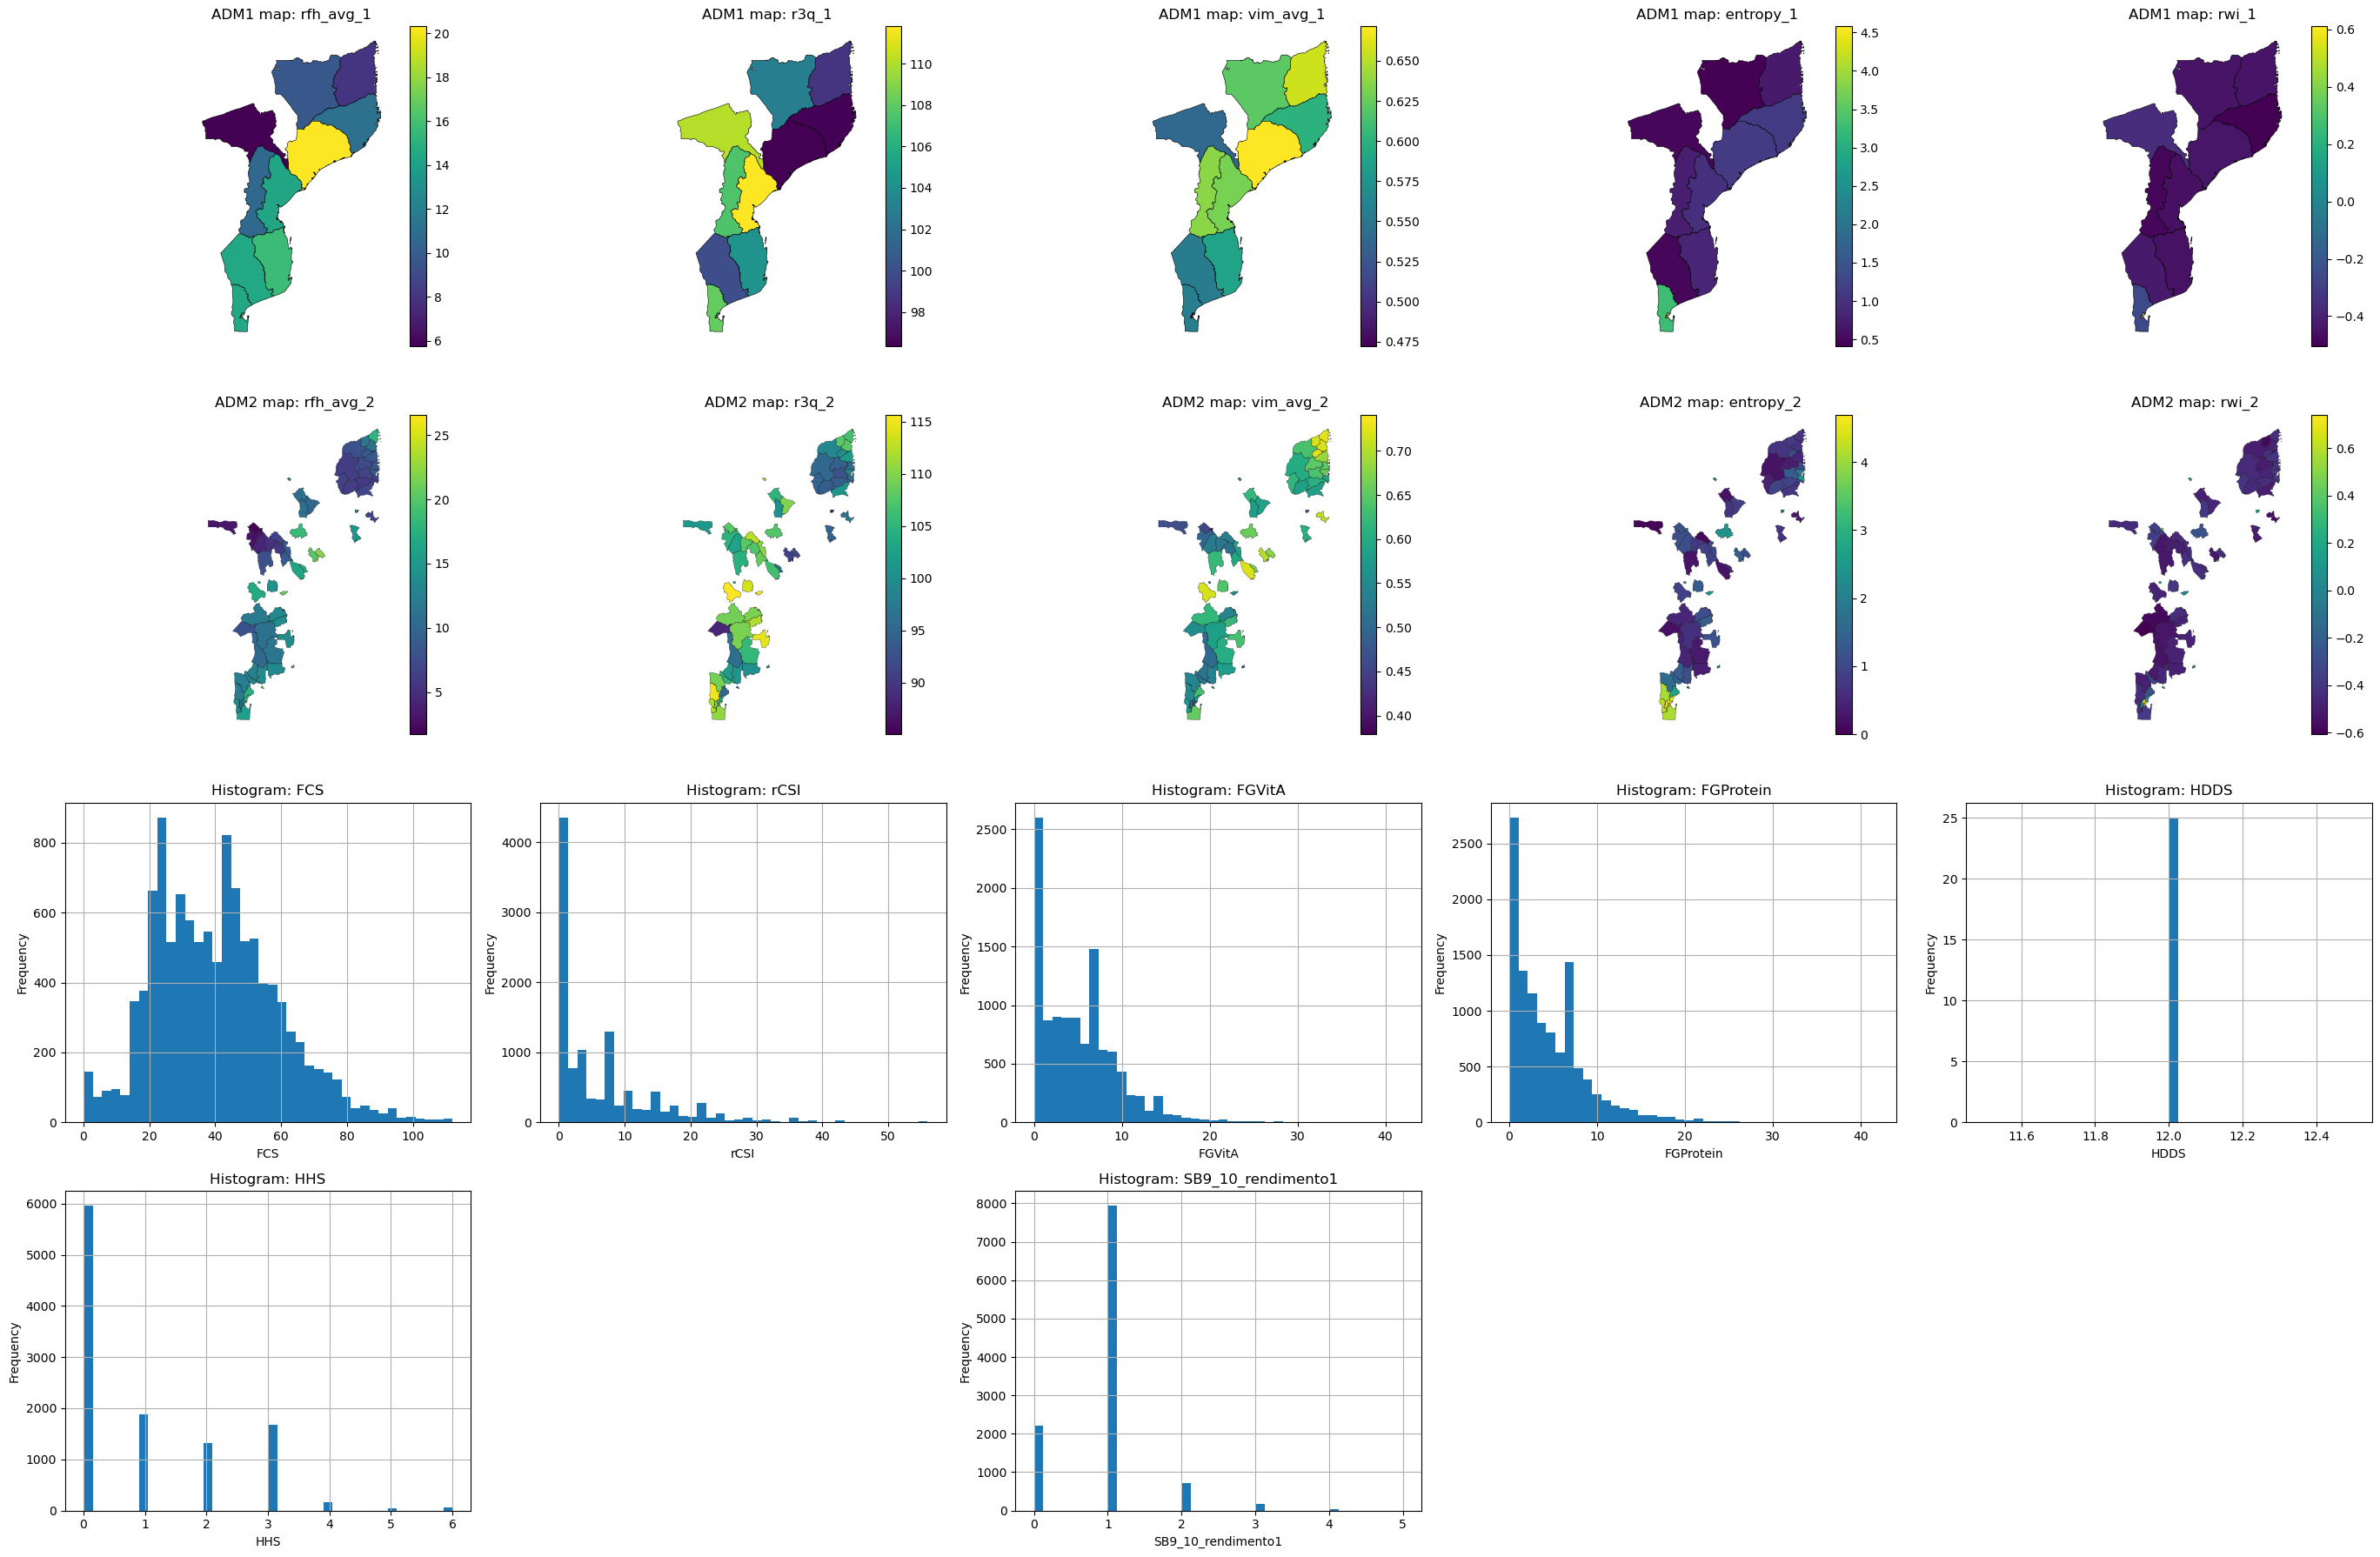

In [72]:
plot_df = df_to_save.copy()

# Convert WKT geometries back to shapely geometries if needed.
for geom_col in ["adm1geometry", "adm2geometry"]:
    if geom_col in plot_df.columns:
        plot_df[geom_col] = plot_df[geom_col].apply(
            lambda x: wkt.loads(x) if isinstance(x, str) else x
        )

adm1_map_vars = [c for c in ["rfh_avg_1", "r3q_1", "vim_avg_1", "entropy_1", "rwi_1"] if c in plot_df.columns]
adm2_map_vars = [c for c in ["rfh_avg_2", "r3q_2", "vim_avg_2", "entropy_2", "rwi_2"] if c in plot_df.columns]
hist_vars = [c for c in ["FCS", "rCSI", "FGVitA", "FGProtein", "FGHIron", "HDDS", "HHS", "SA_escola", "SB9_10_rendimento1", "SH_4_agua_tempo"] if c in plot_df.columns]

adm1_gdf = None
if "adm1geometry" in plot_df.columns and adm1_map_vars:
    adm1_gdf = (
        plot_df[["adm1name", "adm1code", "adm1geometry"] + adm1_map_vars]
        .drop_duplicates(subset=["adm1code"])
        .dropna(subset=["adm1geometry"])
        .copy()
    )
    adm1_gdf = gpd.GeoDataFrame(adm1_gdf, geometry="adm1geometry", crs="EPSG:4326")

adm2_gdf = None
if "adm2geometry" in plot_df.columns and adm2_map_vars:
    adm2_gdf = (
        plot_df[["adm2name", "adm2code", "adm2geometry"] + adm2_map_vars]
        .drop_duplicates(subset=["adm2code"])
        .dropna(subset=["adm2geometry"])
        .copy()
    )
    adm2_gdf = gpd.GeoDataFrame(adm2_gdf, geometry="adm2geometry", crs="EPSG:4326")

n_cols = 5
map_rows = int(adm1_gdf is not None and len(adm1_map_vars) > 0) + int(adm2_gdf is not None and len(adm2_map_vars) > 0)
n_hist_rows = int(np.ceil(len(hist_vars) / n_cols)) if hist_vars else 0
total_rows = map_rows + n_hist_rows

if total_rows == 0:
    print("No maps or histograms available for plotting.")
else:
    fig, axes = plt.subplots(total_rows, n_cols, figsize=(5.5 * n_cols, 4.5 * total_rows))
    axes = np.array(axes).reshape(total_rows, n_cols)

    for ax in axes.ravel():
        ax.axis("off")

    current_row = 0

    if adm1_gdf is not None and adm1_map_vars:
        for i, col in enumerate(adm1_map_vars[:n_cols]):
            ax = axes[current_row, i]
            adm1_gdf.plot(column=col, ax=ax, legend=True, edgecolor="black", linewidth=0.4)
            ax.set_title(f"ADM1 map: {col}")
            ax.axis("off")
        current_row += 1

    if adm2_gdf is not None and adm2_map_vars:
        for i, col in enumerate(adm2_map_vars[:n_cols]):
            ax = axes[current_row, i]
            adm2_gdf.plot(column=col, ax=ax, legend=True, edgecolor="black", linewidth=0.2)
            ax.set_title(f"ADM2 map: {col}")
            ax.axis("off")
        current_row += 1

    for i, col in enumerate(hist_vars):
        row = current_row + (i // n_cols)
        col_pos = i % n_cols
        ax = axes[row, col_pos]
        ax.axis("on")
        s = pd.to_numeric(plot_df[col], errors="coerce").dropna()
        if len(s) == 0:
            ax.axis("off")
            continue
        s.hist(bins=40, ax=ax)
        ax.set_title(f"Histogram: {col}")
        ax.set_xlabel(col)
        ax.set_ylabel("Frequency")

    plt.tight_layout()
    plt.savefig(FIG_PATH, dpi=300, bbox_inches="tight")
    print("Saved figure to:")
    print(FIG_PATH)
    plt.show()